# XGBoost v8 (Hyperparameter Tuning)

What changed from v7:

1. Running a random search over 15 different hyperparameter combinations for model A
2. SMOTE runs once at the start and gets reused across all 15 iterations, way faster than resampling every time
3. Model B only trains once since we are not tuning it
4. Iteration 1 is always the v7 baseline params as a reference point

- v7 got 0.4165 on test, let's see if tuning can push it higher.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data

Same dataset and features as v7.

In [2]:
df = pd.read_parquet('../../../1_download_data/cleansed/modeling_dataset.parquet')
print('shape:', df.shape)

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay','month_avg_cancel_rate', 'month_avg_delay_rate','season_avg_cancel_rate', 'season_avg_delay_rate'
]
features = [f for f in features if f in df.columns]
print(f'using {len(features)} features')

X_train_a = train[features]; y_train_a = train['is_cancelled'].astype(int)
X_val_a   = val[features];   y_val_a   = val['is_cancelled'].astype(int)
X_test_a  = test[features];  y_test_a  = test['is_cancelled'].astype(int)

train_b = train[train['is_cancelled'] == 0]
val_b   = val[val['is_cancelled']     == 0]
test_b  = test[test['is_cancelled']   == 0]
X_train_b = train_b[features]; y_train_b = train_b['is_delayed'].astype(int)
X_val_b   = val_b[features];   y_val_b   = val_b['is_delayed'].astype(int)
X_test_b  = test_b[features];  y_test_b  = test_b['is_delayed'].astype(int)

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

X_train_a = X_train_a.fillna(X_train_a.median())
X_val_a   = X_val_a.fillna(X_train_a.median())
X_test_a  = X_test_a.fillna(X_train_a.median())
X_train_b = X_train_b.fillna(X_train_b.median())
X_val_b   = X_val_b.fillna(X_train_b.median())
X_test_b  = X_test_b.fillna(X_train_b.median())

print(f'Model A: train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B: train: {X_train_b.shape}, val: {X_val_b.shape}')

shape: (24165691, 56)
using 49 features
Model A: train: (2000000, 49), val: (6310951, 49)
Model B: train: (13535123, 49), val: (6199937, 49)


## SMOTE: Run Once

Running SMOTE once here and reusing the resampled data for all 15 iterations. Would take forever if we resampled inside the loop.

In [3]:
# run SMOTE once and reuse for all iterations
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_a_res, y_train_a_res = smote.fit_resample(X_train_a, y_train_a)

print(f'(before SMOTE) cancelled: {y_train_a.sum():,}, not cancelled: {(y_train_a==0).sum():,}')
print(f'(after SMOTE)  cancelled: {y_train_a_res.sum():,}, not cancelled: {(y_train_a_res==0).sum():,}')

weights_b = compute_sample_weight('balanced', y_train_b)
print('resampling done')

(before SMOTE) cancelled: 34,990, not cancelled: 1,965,010
(after SMOTE)  cancelled: 393,002, not cancelled: 1,965,010
resampling done


## Model B: Train Once

We are only tuning model A in this notebook so model B only needs to train once.

model B done
              precision    recall  f1-score   support

     on_time       0.71      0.89      0.79   4087864
     delayed       0.59      0.30      0.40   2112073

    accuracy                           0.69   6199937
   macro avg       0.65      0.60      0.59   6199937
weighted avg       0.67      0.69      0.66   6199937



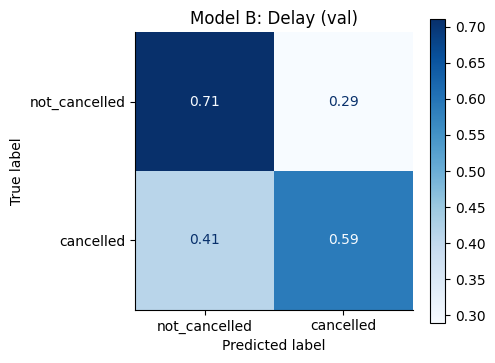

In [4]:
model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')
print(classification_report(model_b.predict(X_val_b), y_val_b,
      target_names=['on_time', 'delayed'], zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val_b, model_b.predict(X_val_b),
    display_labels=['not_cancelled', 'cancelled'],
    ax=ax, colorbar=True, cmap='Blues',
    normalize='true', values_format='.2f'
)
ax.set_title('Model B: Delay (val)')
plt.tight_layout()
plt.show()



## Random Search: 15 Iterations

Testing 15 different hyperparameter combos for model A. The search space is centered around the best params from v7. Iteration 1 is always those exact params so we have a direct comparison point.

The main things we are tuning:
- depth and learning rate: control how complex the trees are
- scale_pos_weight: controls how hard the model tries to catch cancellations
- regularization (alpha, lambda): helps prevent overfitting

In [5]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

np.random.seed(42)
n_iter = 15

# search space centered around v1 iteration 7 params
param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.04, 0.05, 0.06, 0.08],
    'n_estimators':     [400, 500, 600, 800],
    'reg_alpha':        [0.5, 0.8, 1.0, 1.5],
    'reg_lambda':       [1.5, 2.0, 2.5],
    'scale_pos_weight': [5, 10, 15],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

sampled_params = []
for _ in range(n_iter):
    combo = {k: np.random.choice(v) for k, v in param_grid.items()}
    sampled_params.append(combo)

# iteration 0 is always the v1 grid search iteration 7 params
sampled_params[0] = {
    'max_depth': 4, 'learning_rate': 0.04, 'n_estimators': 500,
    'reg_alpha': 0.8, 'reg_lambda': 2.0, 'scale_pos_weight': 10,
    'subsample': 0.8, 'colsample_bytree': 0.8,
}
print(f'starting random search: {n_iter} combinations total')

starting random search: 15 combinations total


In [6]:
search_results = []

for i, params in enumerate(sampled_params):
    print(f'\niter {i+1}/{n_iter}: {params}')

    ma = XGBClassifier(
        **params,
        objective='binary:logistic',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    ma.fit(X_train_a_res, y_train_a_res,
           eval_set=[(X_val_a, y_val_a)],
           verbose=False)

    y_pred = cascade_predict(X_val_a, ma, model_b)
    mf1 = f1_score(y_val_true, y_pred, average='macro')
    cancel_recall = recall_score(y_val_true, y_pred, labels=[2], average='micro')

    print(f'  val macro F1: {mf1:.4f} | cancelled recall: {cancel_recall:.3f}')
    search_results.append({'params': params, 'mf1': mf1, 'cancel_recall': cancel_recall, 'model_a': ma})

print('\nsearch done')


iter 1/15: {'max_depth': 4, 'learning_rate': 0.04, 'n_estimators': 500, 'reg_alpha': 0.8, 'reg_lambda': 2.0, 'scale_pos_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8}
  val macro F1: 0.4257 | cancelled recall: 0.267

iter 2/15: {'max_depth': np.int64(4), 'learning_rate': np.float64(0.05), 'n_estimators': np.int64(600), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(2.5), 'scale_pos_weight': np.int64(5), 'subsample': np.float64(1.0), 'colsample_bytree': np.float64(0.8)}
  val macro F1: 0.4415 | cancelled recall: 0.157

iter 3/15: {'max_depth': np.int64(3), 'learning_rate': np.float64(0.04), 'n_estimators': np.int64(800), 'reg_alpha': np.float64(1.5), 'reg_lambda': np.float64(2.0), 'scale_pos_weight': np.int64(10), 'subsample': np.float64(0.8), 'colsample_bytree': np.float64(0.7)}
  val macro F1: 0.4266 | cancelled recall: 0.269

iter 4/15: {'max_depth': np.int64(3), 'learning_rate': np.float64(0.06), 'n_estimators': np.int64(500), 'reg_alpha': np.float64(0.8), 'reg_lam

## Best Combo

Picking the iteration with the highest val macro F1.

In [7]:
best = max(search_results, key=lambda x: x['mf1'])
best_ma = best['model_a']

print(f'best params: {best["params"]}')
print(f'val macro F1: {best["mf1"]:.4f} | cancelled recall: {best["cancel_recall"]:.3f}')

# show all results sorted so we can see the full picture
results_df = pd.DataFrame([{
    'iter': i+1,
    'depth': r['params']['max_depth'],
    'lr': r['params']['learning_rate'],
    'trees': r['params']['n_estimators'],
    'alpha': r['params']['reg_alpha'],
    'spw': r['params']['scale_pos_weight'],
    'val_f1': round(r['mf1'], 4),
    'cancel_recall': round(r['cancel_recall'], 3),
} for i, r in enumerate(search_results)])
print(results_df.sort_values('val_f1', ascending=False).to_string(index=False))

best params: {'max_depth': np.int64(5), 'learning_rate': np.float64(0.08), 'n_estimators': np.int64(400), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(2.0), 'scale_pos_weight': np.int64(5), 'subsample': np.float64(0.8), 'colsample_bytree': np.float64(0.8)}
val macro F1: 0.4429 | cancelled recall: 0.150
 iter  depth   lr  trees  alpha  spw  val_f1  cancel_recall
    7      5 0.08    400    1.0    5  0.4429          0.150
   15      5 0.03    800    1.0    5  0.4416          0.146
    2      4 0.05    600    1.0    5  0.4415          0.157
   12      5 0.06    400    0.8    5  0.4411          0.151
    4      3 0.06    500    0.8    5  0.4375          0.150
    5      5 0.04    800    1.5   10  0.4320          0.228
   13      3 0.04    400    1.5    5  0.4313          0.163
    9      5 0.05    500    0.5   10  0.4304          0.237
   14      3 0.03    400    1.0    5  0.4290          0.185
    3      3 0.04    800    1.5   10  0.4266          0.269
    1      4 0.04    500  

## Val Results

How does the best model do on validation?

val cascade macro F1: 0.4429
              precision    recall  f1-score   support

     on_time       0.88      0.71      0.79   5127027
     delayed       0.29      0.56      0.38   1072910
   cancelled       0.17      0.15      0.16    111014

    accuracy                           0.68   6310951
   macro avg       0.45      0.47      0.44   6310951
weighted avg       0.77      0.68      0.71   6310951



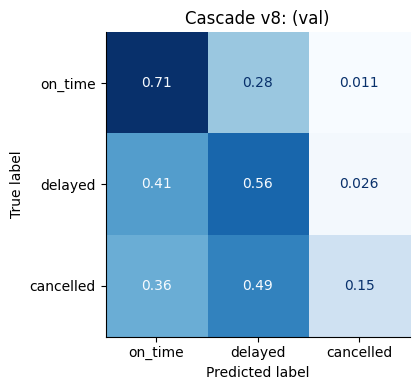

In [8]:
y_val_pred = cascade_predict(X_val_a, best_ma, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Cascade v8: (val)')
plt.tight_layout()
plt.show()

## Test Set Results

Running on test exactly once with the best params from val.

test cascade macro F1: 0.4278
              precision    recall  f1-score   support

     on_time       0.85      0.63      0.72   3091391
     delayed       0.32      0.58      0.41    863057
   cancelled       0.12      0.20      0.15    123191

    accuracy                           0.61   4077639
   macro avg       0.43      0.47      0.43   4077639
weighted avg       0.71      0.61      0.64   4077639



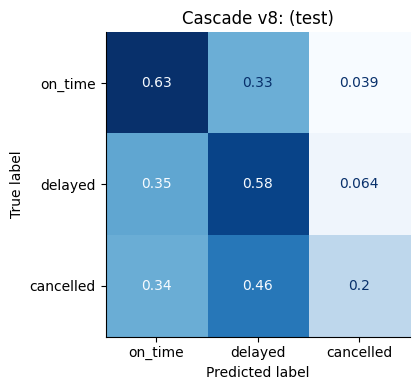

In [9]:
y_test_pred = cascade_predict(X_test_a, best_ma, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Cascade v8: (test)')
plt.tight_layout()
plt.show()

## Version Progression v1-v8

Tracking macro F1 across all versions to see the full picture.

          model  val macro F1  test macro F1
v1 flights only        0.3054         0.2954
    v2 +weather        0.3641         0.3594
    v3 +weights        0.3750         0.3770
        v4 +spw        0.2795         0.2614
v5 cascade +spw        0.3624         0.3582
      v6 +SMOTE        0.4035         0.4152
    v7 new data        0.4302         0.4199
       v8 tuned        0.4429         0.4278


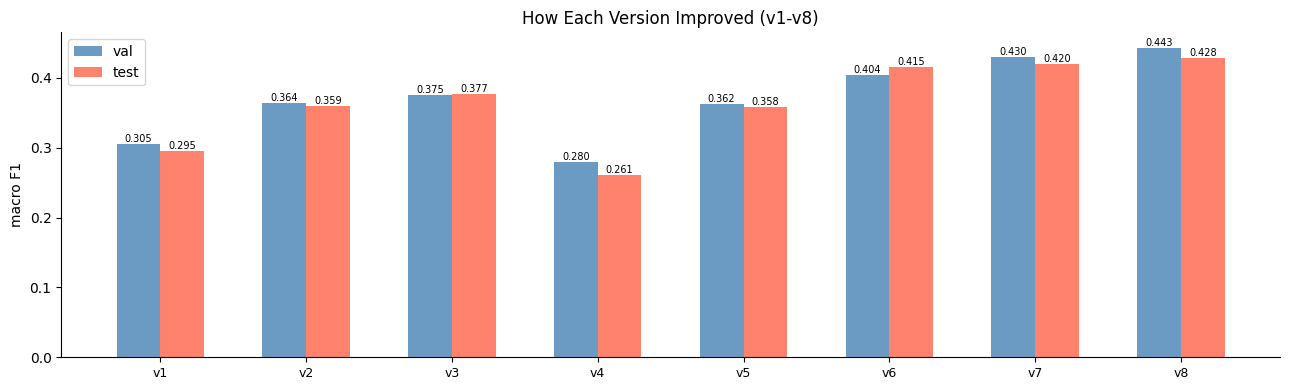

In [4]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614
v5_val,  v5_test  = 0.3624, 0.3582
v6_val,  v6_test  = 0.4035, 0.4152
v7_val,  v7_test  = 0.4302, 0.4199

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE',
                      'v7 new data', 'v8 tuned'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, v7_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, v7_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(13, 4))
x = np.arange(8)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, v7_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, v7_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=7)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('How Each Version Improved (v1-v8)')
ax.legend()
plt.tight_layout()
plt.show()

# Feature Importance for Each Model

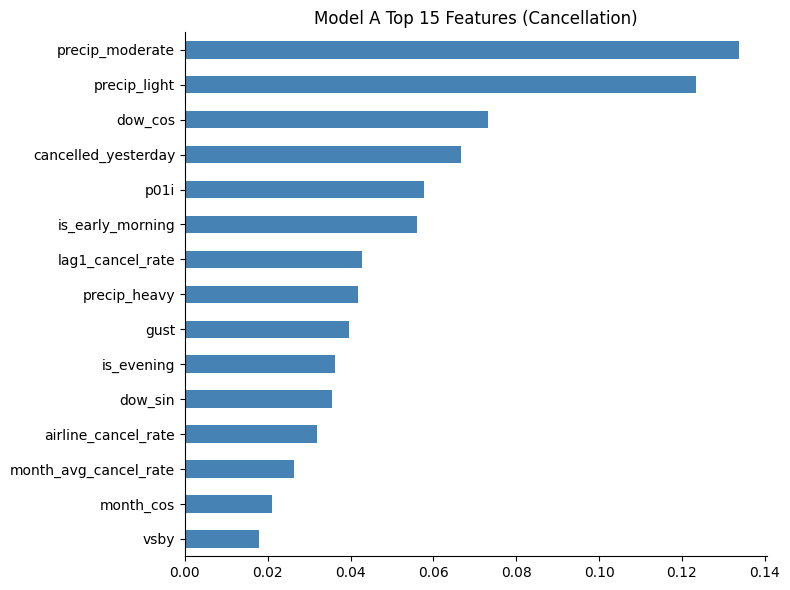

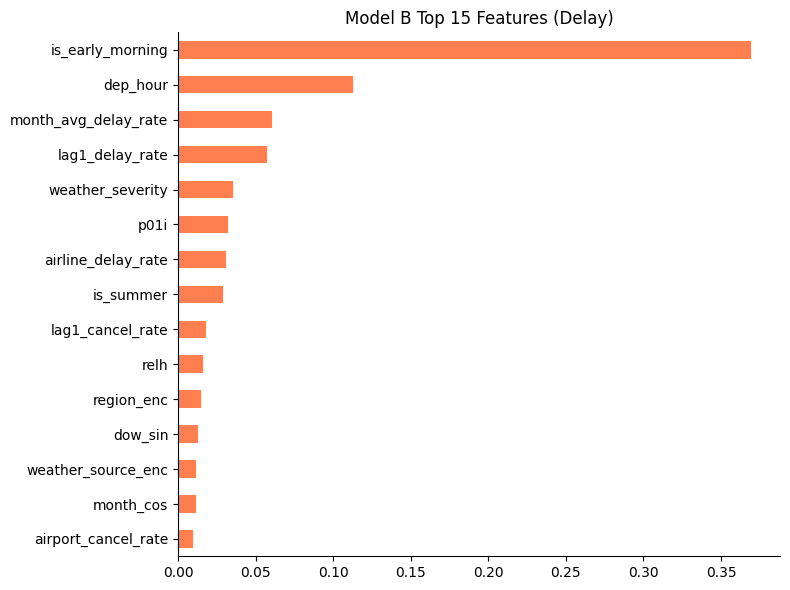

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_a = pd.Series(best_ma.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_a.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Model A Top 15 Features (Cancellation)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_b = pd.Series(model_b.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_b.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Model B Top 15 Features (Delay)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Summary

Test F1 improved from 0.4199 in v7 to 0.4278 here. Looking at the search results, the top combos all used scale_pos_weight=5 which is lower than the spw=10 we used in v7. The seasonal and lag features are giving the model enough signal on cancellations that it doesn't need to push as hard with the class weight.

For model A, precipitation features dominate: precip_moderate and precip_light are the top two, with cancelled_yesterday and lag1_cancel_rate also showing up as important. The new month_avg_cancel_rate feature made it into the top 15 as well, which confirms the seasonal averages are adding real signal.

For model B, is_early_morning and dep_hour are by far the strongest predictors of delays, with month_avg_delay_rate and lag1_delay_rate close behind. Departure time matters a lot more for delays than for cancellations.

The tradeoff is still consistent: lower spw gets better macro F1 but cancelled recall drops, higher spw catches more cancellations but overall F1 suffers. There is no setting that wins on both at once.

Next up is threshold tuning, which tries to squeeze more out of these models without any retraining.

## Save

Run after everything looks good.

In [11]:
import joblib, os
os.makedirs('./modelos', exist_ok=True)
joblib.dump(best_ma, './models/model_a_v8.pkl')
joblib.dump(model_b, './models/model_b_v8.pkl')
print('saved model_a_v8.pkl and model_b_v8.pkl')



saved model_a_v8.pkl and model_b_v8.pkl
